In [77]:
import networkx as nx
import pandas as pd
from networkx.algorithms import community
import community as community_louvain
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from collections import Counter
from scipy.stats import entropy
import numpy as np
import math
import random


pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

## Generazione grafo

In [12]:
hero_network_dataframe = pd.read_csv("../data/raw/dati marvel/hero-network.csv")

# Pulizia dei nomi
hero_network_dataframe['hero1'] = hero_network_dataframe['hero1'].str.split('/').str[0].str.strip()
hero_network_dataframe['hero2'] = hero_network_dataframe['hero2'].str.split('/').str[0].str.strip()

hero_graph = nx.from_pandas_edgelist(hero_network_dataframe, source='hero1', target='hero2')

print("GRAFO INIZIALE: \n")
print(f"Caratteristiche grafo: {hero_graph.number_of_nodes()} nodi, {hero_graph.number_of_edges()} archi")
print(f"Self-loops: {nx.number_of_selfloops(hero_graph)}")
print(f"Il grafo è connesso? {nx.is_connected(hero_graph)}")
print("----------------------------------------------------\n")




# Rimozione dei self loops
hero_graph.remove_edges_from(nx.selfloop_edges(hero_graph))

print("RIMOZIONE SELF LOOPS: \n")
print(f"Self-loops dopo: {nx.number_of_selfloops(hero_graph)}")
print(f"Grafo post rimozione self loops: {hero_graph.number_of_nodes()} nodi, {hero_graph.number_of_edges()} archi")
print(f"Il grafo è ora connesso? {nx.is_connected(hero_graph)}")
print("----------------------------------------------------\n")




# Componente principale, si estrae quella e si usa quella
largest_cc = max(nx.connected_components(hero_graph), key=len)
hero_graph = hero_graph.subgraph(largest_cc).copy()

print("ESTRAGGO IL SOTTOGRAFO PRINCIPALE: \n")
print(f"Componente principale: {hero_graph.number_of_nodes()} nodi, {hero_graph.number_of_edges()} archi")
print(f"Il grafo è ora connesso? {nx.is_connected(hero_graph)}")

GRAFO INIZIALE: 

Caratteristiche grafo: 6413 nodi, 167095 archi
Self-loops: 12
Il grafo è connesso? False
----------------------------------------------------

RIMOZIONE SELF LOOPS: 

Self-loops dopo: 0
Grafo post rimozione self loops: 6413 nodi, 167083 archi
Il grafo è ora connesso? False
----------------------------------------------------

ESTRAGGO IL SOTTOGRAFO PRINCIPALE: 

Componente principale: 6395 nodi, 167027 archi
Il grafo è ora connesso? True


## Triadi
Teoria triadi:
1. Definizione triade: sottografo formato da 3 nodi e dalle relazioni tra loro.
2. Triadi nei grafi indiretti:
    1. triade chiusa = triangolo (tutti e 3 gli eroi sono collegati tra loro).
    2. triade aperta = 2 legami su 3 (forma a "V")

### Elenco delle triadi chiuse e delle triadi aperte

In [66]:
# 1) Elenco delle triadi chiuse --> serve per vedere quali eroi formano una triade:
triads = []

for node in hero_graph.nodes():
    neighbors = list(hero_graph.neighbors(node))
    for i in range(len(neighbors)):
        for j in range(i + 1, len(neighbors)):
            if hero_graph.has_edge(neighbors[i], neighbors[j]):
                triad = tuple(sorted([node, neighbors[i], neighbors[j]]))
                triads.append(triad)

triads = list(set(triads))  # rimuove duplicati con "set", poi converte in "list" --> è una lista in cui ogni tupla = una triade chiusa.
                            # esempio: triads = [
                            #    ('BLACK PANTHER/T\'CHAL', 'LITTLE, ABNER', 'PRINCESS ZANDA'),
                            #    ('STEELE, SIMON/WOLFGA', 'ERWIN, CLYTEMNESTRA', 'FORTUNE, DOMINIC'),
                            #    ...]
triads_df = pd.DataFrame(triads, columns=["hero_1", "hero_2", "hero_3"])

print("ELENCO TRIADI CHIUSE: \n")
print(triads_df.head(10))
print("----------------------------------------------------\n")




# 2) Elenco delle Triadi aperte (coppia di vicini non collegati tra loro):
open_triads = []

for node in hero_graph.nodes():
    neighbors = list(hero_graph.neighbors(node))
    for i in range(len(neighbors)):
        for j in range(i + 1, len(neighbors)):
            if not hero_graph.has_edge(neighbors[i], neighbors[j]):
                open_triad = tuple(sorted([node, neighbors[i], neighbors[j]]))
                open_triads.append(open_triad)

open_triads = list(set(open_triads)) # rimuove duplicati con "set", poi converte in "list" --> è una lista in cui ogni tupla = una triade aperta.

open_triads_df = pd.DataFrame(open_triads, columns=["hero_1", "hero_2", "hero_3"]) # conversione in DataFrame

print("ELENCO TRIADI APERTE: \n")
print(open_triads_df.head(10))
print("----------------------------------------------------\n")



ELENCO TRIADI CHIUSE: 

              hero_1                hero_2           hero_3
0      ABSORBING MAN      HELA [ASGARDIAN]         MEPHISTO
1      BLACK PANTHER         JARVIS, EDWIN    THUNDERSTRIKE
2            CR'REEE                  LUNA      QUICKSILVER
3  CAPTAIN MARVEL II       MCCABE, LINDSAY    SCARLET WITCH
4    CAPTAIN AMERICA           COLOSSUS II    SHOOTING STAR
5           DARKSTAR              KREDDICK            THING
6           FIRESTAR  HAWKEYE DOPPELGANGER  INVISIBLE WOMAN
7             BEETLE                  NOVA       WONDER MAN
8    CAPTAIN BRITAIN               CR'REEE           VISION
9        DR. DECIBEL               FOXFIRE      HYPERION II
----------------------------------------------------

ELENCO TRIADI APERTE: 

                 hero_1                hero_2                hero_3
0       CAPTAIN AMERICA  RICHARDS, FRANKLIN B                SVAROG
1           ANCIENT ONE                  HULK                SOLARR
2      GILBERT, ROXANNE           

### Numero di triadi aperte e chiuse per nodo

NUMERO TRIADI CHIUSE PER PERSONAGGIO: 

hero
CAPTAIN AMERICA    88860
SPIDER-MAN         73695
IRON MAN           71775
THING              69264
SCARLET WITCH      69037
WOLVERINE          68630
MR. FANTASTIC      68122
HUMAN TORCH        66860
VISION             66269
THOR               64770
Name: count, dtype: int64
----------------------------------------------------

NUMERO TRIADI APERTE PER PERSONAGGIO: 

hero
CAPTAIN AMERICA    1775339
SPIDER-MAN         1496576
IRON MAN           1148242
THING               998492
MR. FANTASTIC       947445
WOLVERINE           930004
HUMAN TORCH         925940
SCARLET WITCH       867269
THOR                833847
BEAST               802036
Name: count, dtype: int64
----------------------------------------------------



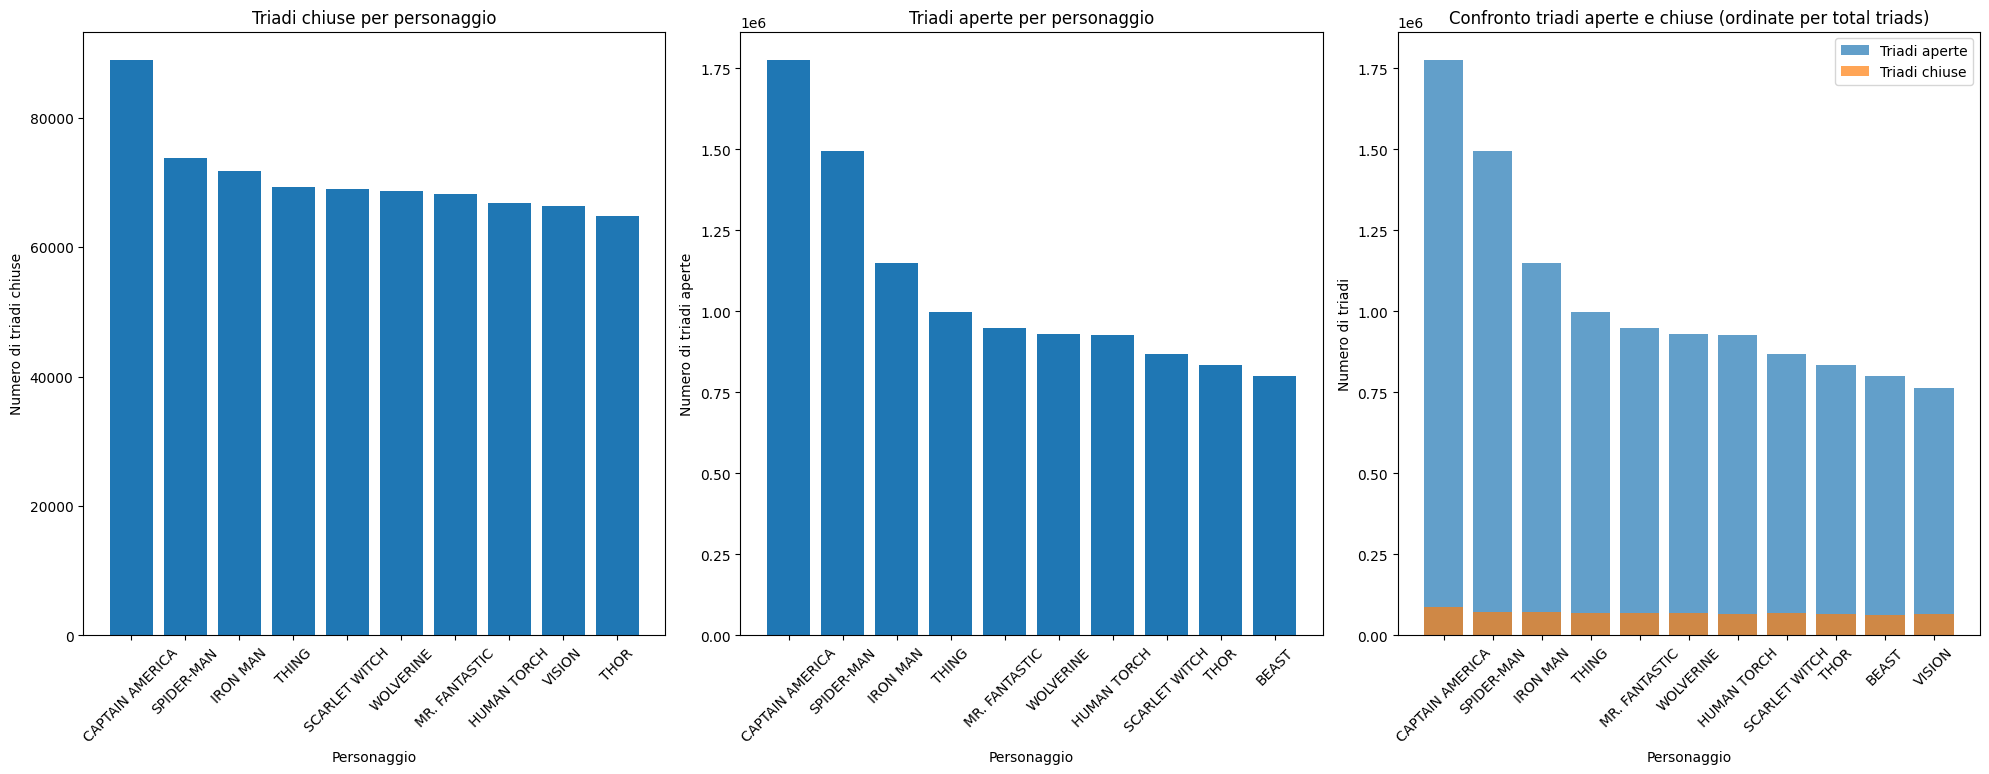

In [67]:
# 3) Numero di triangoli per nodo --> ogni valore indica quanti triangoli coinvolgono quel nodo.
#    --> Risponde alla domanda: Quante triadi chiuse per personaggio?
close_triads_per_node = triads_df.melt(value_name="hero", var_name="position")

triads_count = close_triads_per_node["hero"].value_counts()

print("NUMERO TRIADI CHIUSE PER PERSONAGGIO: \n")
print(triads_count.head(10))
print("----------------------------------------------------\n")




# 4) Numero di triadi aperte per nodo --> ogni valore indica quante triadi aperte coinvolgono quel nodo.
#    --> Risponde alla domanda: Quante triadi aperte per personaggio?
open_triads_per_node = open_triads_df.melt(value_name="hero", var_name="position")

open_triads_count = open_triads_per_node["hero"].value_counts()

print("NUMERO TRIADI APERTE PER PERSONAGGIO: \n")
print(open_triads_count.head(10))
print("----------------------------------------------------\n")




# A) Controllo di coerenza triadi aperte e chiuse:
#def count_edges(triad, G):
#    a, b, c = triad
#    return (G.has_edge(a, b) + G.has_edge(a, c) + G.has_edge(b, c))

#open_triads_df["n_edges"] = open_triads_df.apply(lambda row: count_edges((row.hero_1, row.hero_2, row.hero_3), G), axis=1)
#k = open_triads_df["n_edges"].value_counts()
#print(k)
# per le triadi aperte deve uscire "2" (altrimenti sbagliato), per le triadi chiuse deve uscire "3"
#triads_df["n_edges"] = triads_df.apply(lambda row: count_edges((row.hero_1, row.hero_2, row.hero_3), G), axis=1)
#h = triads_df["n_edges"].value_counts()
#print(h)




# Plot
# Top 10
closed_top = triads_count.head(10)
open_top = open_triads_count.head(10)

# Figura con 3 subplot affiancati
fig, axes = plt.subplots(1, 3, figsize=(20, 8))

# =========================
# PLOT 1: Triadi chiuse
# =========================
axes[0].bar(closed_top.index, closed_top.values)
axes[0].set_title("Triadi chiuse per personaggio")
axes[0].set_xlabel("Personaggio")
axes[0].set_ylabel("Numero di triadi chiuse")
axes[0].tick_params(axis='x', rotation=45)

# =========================
# PLOT 2: Triadi aperte
# =========================
axes[1].bar(open_top.index, open_top.values)
axes[1].set_title("Triadi aperte per personaggio")
axes[1].set_xlabel("Personaggio")
axes[1].set_ylabel("Numero di triadi aperte")
axes[1].tick_params(axis='x', rotation=45)

# =========================
# PLOT 3: Confronto sovrapposto (scala comune)
# =========================

# Insieme comune di personaggi
common_heroes = list(set(closed_top.index).union(set(open_top.index)))

# Riallineamento dei dati
closed_common = triads_count.reindex(common_heroes).fillna(0)
open_common = open_triads_count.reindex(common_heroes).fillna(0)

# Totale triadi per personaggio
total_triads = closed_common + open_common

# Ordinamento decrescente
sorted_idx = total_triads.sort_values(ascending=False).index

# Riordino coerente
closed_sorted = closed_common.loc[sorted_idx]
open_sorted = open_common.loc[sorted_idx]

x = range(len(sorted_idx))

axes[2].bar(x, open_sorted.values, alpha=0.7, label="Triadi aperte")
axes[2].bar(x, closed_sorted.values, alpha=0.7, label="Triadi chiuse")

axes[2].set_xticks(x)
axes[2].set_xticklabels(sorted_idx, rotation=45)
axes[2].set_title("Confronto triadi aperte e chiuse (ordinate per total triads)")
axes[2].set_xlabel("Personaggio")
axes[2].set_ylabel("Numero di triadi")
axes[2].legend()

plt.tight_layout()
plt.show()


### Totale triadi

In [68]:
# 5) Totale triadi:
print("TOTALE TRIADI: \n")
print(f"Numero di triadi chiuse: {len(triads_df):,}") # nota: ogni triangolo viene contato 1 volta
print(f"Numero di triadi aperte: {len(open_triads_df):,}")
print(f"Percentuale di triplette di nodi che sono triangoli: {round((len(triads_df)/(len(triads_df)+len(open_triads_df)))*100, 2)}%")


TOTALE TRIADI: 

Numero di triadi chiuse: 3,244,871
Numero di triadi aperte: 40,239,692
Percentuale di triplette di nodi che sono triangoli: 7.46%


### Triadi per community (Louvain)

Numero di comunità trovate: 21
--------------------------------------------------

TRIADI (prime 10) CON COMMUNITY: 

              hero_1                hero_2           hero_3  community_1  community_2  community_3  intra_community
0      ABSORBING MAN      HELA [ASGARDIAN]         MEPHISTO            7            7            7             True
1      BLACK PANTHER         JARVIS, EDWIN    THUNDERSTRIKE            0            0            4            False
2            CR'REEE                  LUNA      QUICKSILVER            3            4            4            False
3  CAPTAIN MARVEL II       MCCABE, LINDSAY    SCARLET WITCH            4            0            0            False
4    CAPTAIN AMERICA           COLOSSUS II    SHOOTING STAR            0            3            4            False
5           DARKSTAR              KREDDICK            THING            4            4           10            False
6           FIRESTAR  HAWKEYE DOPPELGANGER  INVISIBLE WOMAN           

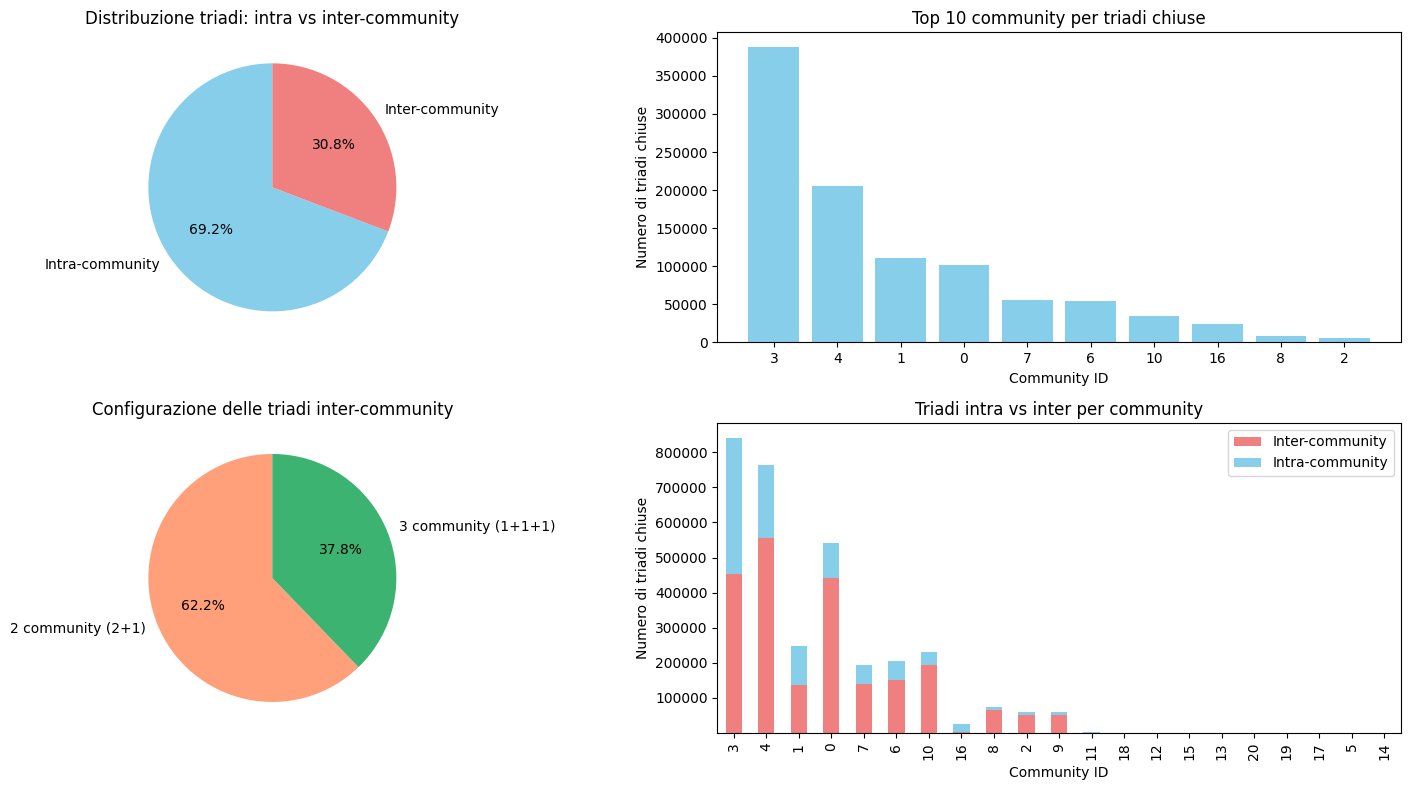

In [69]:
# 6) Triadi per community (Louvain)
partition = community_louvain.best_partition(hero_graph)
num_communities = len(set(partition.values()))
print(f"Numero di comunità trovate: {num_communities}")
print("--------------------------------------------------\n")




triads_df["community_1"] = triads_df["hero_1"].map(partition)
triads_df["community_2"] = triads_df["hero_2"].map(partition)
triads_df["community_3"] = triads_df["hero_3"].map(partition)

triads_df["intra_community"] = ((triads_df["community_1"] == triads_df["community_2"]) & (triads_df["community_2"] == triads_df["community_3"]))

print("TRIADI (prime 10) CON COMMUNITY: \n")
print(triads_df.head(10))
print("--------------------------------------------------\n")




print("CONTEGGIO TRIADI INTRA / INTER COMMUNITY:\n")
n_intra = triads_df["intra_community"].sum()
n_inter = (triads_df["intra_community"] == False).sum()
print(f"Numero di triadi intra-community: {n_intra}")
print(f"Numero di triadi inter-community: {n_inter}")

intra_ratio = triads_df["intra_community"].mean() * 100

print(f"Percentuale di triadi intra-community: {intra_ratio:.2f}%")
print(f"Percentuale di triadi inter-community: {100 - intra_ratio:.2f}%")
print("--------------------------------------------------\n")




community_triads = (triads_df[triads_df["intra_community"]].groupby("community_1").size().sort_values(ascending=False))

print("COMMUNITY CON PIÙ TRIADI CHIUSE:\n")
print(community_triads.head(10))
print("--------------------------------------------------\n")




# Numero di community distinte per ciascuna triade
triads_df["num_communities"] = triads_df[
    ["community_1", "community_2", "community_3"]
].nunique(axis=1)

# Consideriamo solo le triadi inter-community
inter_triads = triads_df[~triads_df["intra_community"]]

# Conteggio delle configurazioni (2 community vs 3 community)
inter_config_counts = inter_triads["num_communities"].value_counts().sort_index()

# Percentuali rispetto al totale delle triadi inter-community
inter_config_perc = inter_config_counts / inter_config_counts.sum() * 100

print("DISTRIBUZIONE TRIADI INTER-COMMUNITY PER NUMERO DI COMMUNITY DISTINTE:")
print(inter_config_counts)
print("\nPercentuali:")
print(inter_config_perc.round(2))
print("--------------------------------------------------\n")






# Plot
# Creiamo una figura unica: 2 righe x 2 colonne
fig = plt.figure(figsize=(15, 8))

# -------------------------------
# 1) Pie chart (overview) – riga 0, colonna 0
ax1 = plt.subplot2grid((2,2), (0,0), rowspan=1)
counts = triads_df["intra_community"].value_counts()
labels = ["Intra-community", "Inter-community"]
ax1.pie(counts, labels=labels, autopct="%1.1f%%", startangle=90, colors=["skyblue","lightcoral"])
ax1.set_title("Distribuzione triadi: intra vs inter-community")

# -------------------------------
# 2) Bar chart top 10 community – riga 0, colonna 1
ax2 = plt.subplot2grid((2,2), (0,1))
top_communities = community_triads.head(10)
ax2.bar(top_communities.index.astype(str), top_communities.values, color="skyblue")
ax2.set_xlabel("Community ID")
ax2.set_ylabel("Numero di triadi chiuse")
ax2.set_title("Top 10 community per triadi chiuse")

# -------------------------------
# 3) Stacked bar chart – riga 1, colonna 1
ax3 = plt.subplot2grid((2,2), (1,1))
community_counts = (triads_df.groupby(["community_1", "intra_community"]).size().unstack(fill_value=0))
community_counts = community_counts.sort_values(True, ascending=False)  # ordina per triadi chiuse
community_counts.plot(kind="bar", stacked=True, ax=ax3, color=["lightcoral","skyblue"], legend=False)
ax3.set_xlabel("Community ID")
ax3.set_ylabel("Numero di triadi chiuse")
ax3.set_title("Triadi intra vs inter per community")
ax3.legend(["Inter-community","Intra-community"])

# -------------------------------
# 4) Pie chart – configurazioni delle triadi inter-community (riga 1, colonna 0)
ax4 = plt.subplot2grid((2,2), (1,0))

labels = []
sizes = []

if 2 in inter_config_perc.index:
    labels.append("2 community (2+1)")
    sizes.append(inter_config_perc.loc[2])

if 3 in inter_config_perc.index:
    labels.append("3 community (1+1+1)")
    sizes.append(inter_config_perc.loc[3])

ax4.pie(sizes, labels=labels, autopct="%1.1f%%", startangle=90, colors=["lightsalmon", "mediumseagreen"])
ax4.set_title("Configurazione delle triadi inter-community")

# -------------------------------
plt.tight_layout()
plt.show()


### Triadi e assortatività
1. Obiettivo: Analizzare se le triadi tendono a coinvolgere nodi con: grado simile o grado diverso.
2. Misura 1: Varianza dei gradi nella triade (misura standard di assortatività locale)
    1. cosa facciamo: Per ogni triade calcoliamo: $Var(k_u, k_v, k_w)$
    2. Come si legge:
        1. valore basso --> gradi simili
        2. valore alto --> gradi diversi

               mean_degree_variance  mean_degree_range
Triadi chiuse         194704.090662         693.442477
Triadi aperte         298290.070011         871.130854


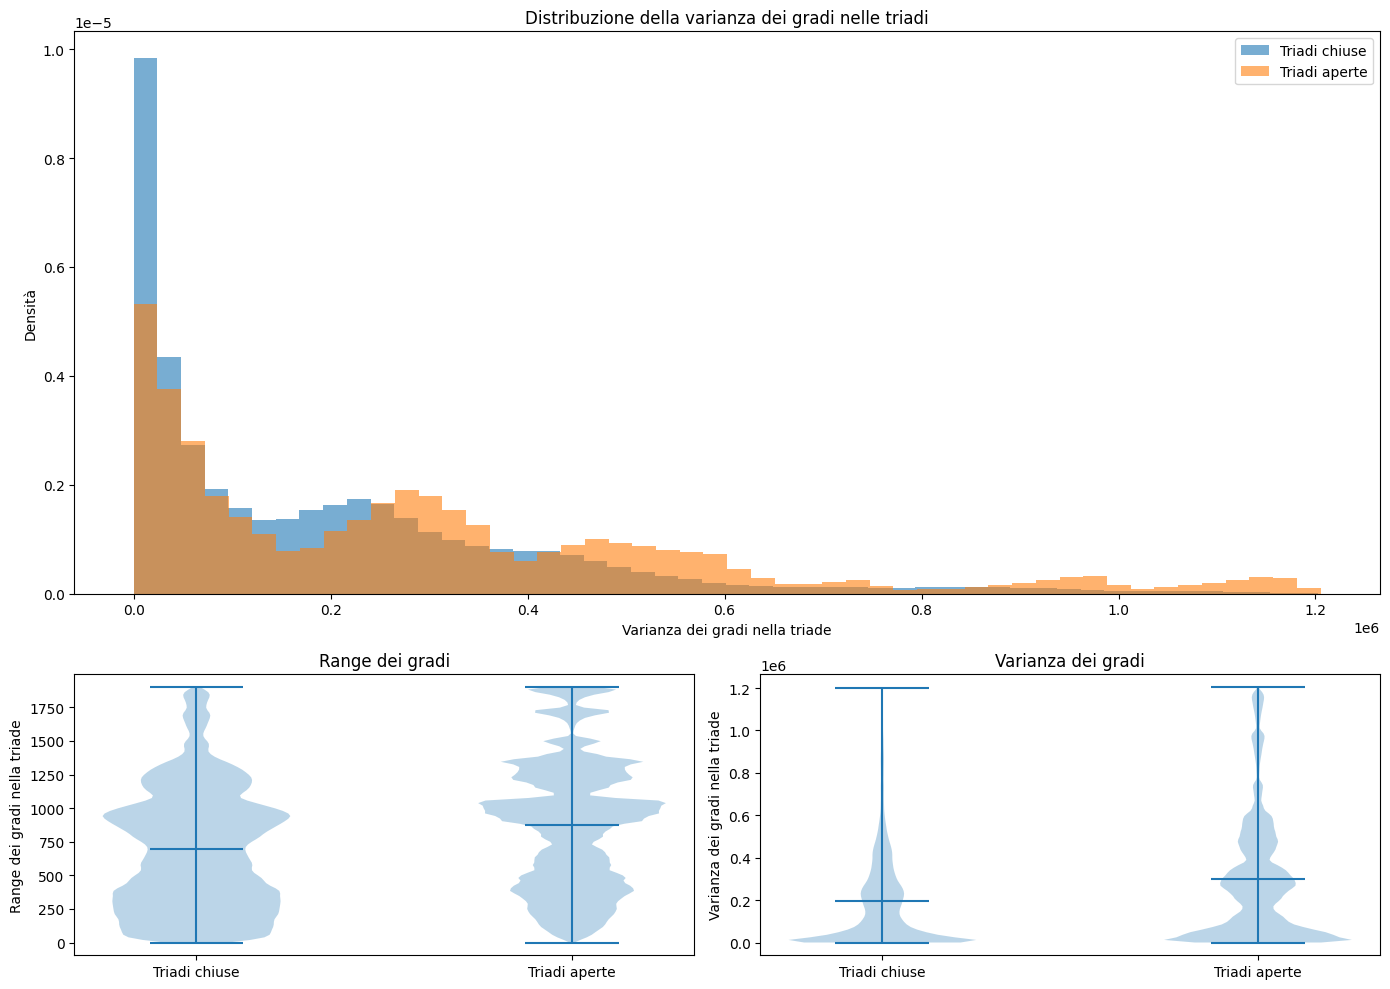

In [ ]:
degrees = dict(hero_graph.degree())

# Aggiungo i gradi al DataFrame delle triadi:
triads_df["deg_1"] = triads_df["hero_1"].map(degrees)
triads_df["deg_2"] = triads_df["hero_2"].map(degrees)
triads_df["deg_3"] = triads_df["hero_3"].map(degrees)

open_triads_df["deg_1"] = open_triads_df["hero_1"].map(degrees)
open_triads_df["deg_2"] = open_triads_df["hero_2"].map(degrees)
open_triads_df["deg_3"] = open_triads_df["hero_3"].map(degrees)


# Misura 1: Varianza dei gradi nella triade
triads_df["degree_variance"] = triads_df[["deg_1", "deg_2", "deg_3"]].var(axis=1)
open_triads_df["degree_variance"] = open_triads_df[["deg_1", "deg_2", "deg_3"]].var(axis=1)

# Misura 2: degree range
triads_df["degree_range"] = (
    triads_df[["deg_1","deg_2","deg_3"]].max(axis=1)
    - triads_df[["deg_1","deg_2","deg_3"]].min(axis=1)
)

open_triads_df["degree_range"] = (
    open_triads_df[["deg_1","deg_2","deg_3"]].max(axis=1)
    - open_triads_df[["deg_1","deg_2","deg_3"]].min(axis=1)
)


summary = pd.DataFrame({
    "mean_degree_variance": [
        triads_df["degree_variance"].mean(),
        open_triads_df["degree_variance"].mean()
    ],
    "mean_degree_range": [
        triads_df["degree_range"].mean(),
        open_triads_df["degree_range"].mean()
    ]
}, index=["Triadi chiuse","Triadi aperte"])

print(summary)





# plot
# Figura complessiva
fig = plt.figure(figsize=(14, 10))
gs = GridSpec(2, 2, height_ratios=[2, 1])  # riga sopra più alta

# =========================
# PLOT 1 (riga sopra, tutta la larghezza)
# =========================
ax1 = fig.add_subplot(gs[0, :])

ax1.hist(
    triads_df["degree_variance"],
    bins=50,
    alpha=0.6,
    density=True,
    label="Triadi chiuse"
)

ax1.hist(
    open_triads_df["degree_variance"],
    bins=50,
    alpha=0.6,
    density=True,
    label="Triadi aperte"
)

ax1.set_xlabel("Varianza dei gradi nella triade")
ax1.set_ylabel("Densità")
ax1.set_title("Distribuzione della varianza dei gradi nelle triadi")
ax1.legend()

# =========================
# PLOT 2 (riga sotto, colonna sinistra)
# =========================
ax2 = fig.add_subplot(gs[1, 0])

ax2.violinplot(
    [triads_df["degree_range"], open_triads_df["degree_range"]],
    showmeans=True,
    showextrema=True
)

ax2.set_xticks([1, 2])
ax2.set_xticklabels(["Triadi chiuse", "Triadi aperte"])
ax2.set_ylabel("Range dei gradi nella triade")
ax2.set_title("Range dei gradi")

# =========================
# PLOT 3 (riga sotto, colonna destra)
# =========================
ax3 = fig.add_subplot(gs[1, 1])

ax3.violinplot(
    [triads_df["degree_variance"], open_triads_df["degree_variance"]],
    showmeans=True,
    showextrema=True
)

ax3.set_xticks([1, 2])
ax3.set_xticklabels(["Triadi chiuse", "Triadi aperte"])
ax3.set_ylabel("Varianza dei gradi nella triade")
ax3.set_title("Varianza dei gradi")

plt.tight_layout()
plt.show()


## Clique
Per evitare strutture triviali, l'analisi delle clique è stata limitata a sottografi completamente connessi di dimensione k >= 3.

### Numero e dimensione delle clique massime

Numero e dimensione delle clique (k >= 3): 

count    1.638241e+06
mean     3.626122e+01
std      1.059311e+01
min      3.000000e+00
25%      2.900000e+01
50%      3.600000e+01
75%      4.300000e+01
max      1.110000e+02
dtype: float64
----------------------------------------------------



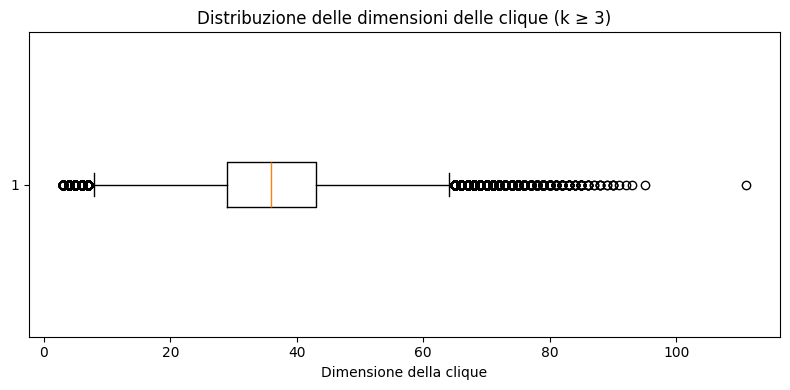

In [5]:
# Teoria Clique:
#   1) Definizione Clique: una clique è un sottografo completamente connesso: cioè un 
#      sottografo dove ogni nodo è direttamente connesso con tutti gli altri nodi.
#   2) Densità: una clique ha network_density = 1, ciò significa che tutte le possibili connessioni esistono.
# -------------------------------------------------------------------------------------------------
# -------------------------------------------------------------------------------------------------
# -------------------------------------------------------------------------------------------------



cliques = [c for c in nx.find_cliques(hero_graph) if len(c) >= 3]
clique_sizes = pd.Series([len(c) for c in cliques])

print("Numero e dimensione delle clique (k >= 3): \n")
print(clique_sizes.describe())
print("----------------------------------------------------\n")



# Plot
plt.figure(figsize=(8, 4))
plt.boxplot(clique_sizes, vert=False)
plt.xlabel("Dimensione della clique")
plt.title("Distribuzione delle dimensioni delle clique (k >= 3)")
plt.tight_layout()
plt.show()

### Distribuzione delle dimensioni delle clique

Distribuzione delle dimensioni delle clique (k >= 3): 

3      106
4      210
5      316
6      555
7      882
      ... 
91       1
92       1
93       1
95       1
111      1
Name: count, Length: 93, dtype: int64
----------------------------------------------------



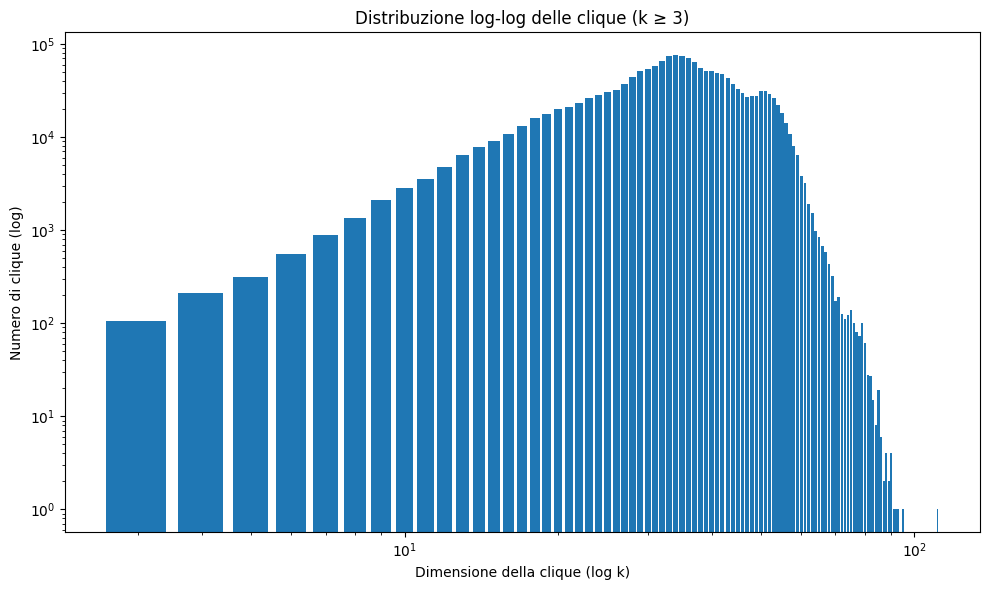

In [6]:
clique_size_dist = clique_sizes.value_counts().sort_index()

print("Distribuzione delle dimensioni delle clique (k >= 3): \n")
print(clique_size_dist)
print("----------------------------------------------------\n")



# Plot
plt.figure(figsize=(10, 6))
plt.bar(clique_size_dist.index, clique_size_dist.values)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Dimensione della clique (log k)")
plt.ylabel("Numero di clique (log)")
plt.title("Distribuzione log-log delle clique (k ≥ 3)")
plt.tight_layout()
plt.show()

### Personaggi che partecipano alle clique più grandi e Centralità basata sulle clique

Clique massime (dimensione = 111):

[['CAPTAIN AMERICA', 'IRON MAN/TONY STARK ', 'SCARLET WITCH/WANDA ', 'VISION ', 'WONDER MAN/SIMON WIL', 'WASP/JANET VAN DYNE ', 'THOR/DR. DONALD BLAK', 'HAWK', 'THING/BENJAMIN J. GR', 'MR. FANTASTIC/REED R', 'INVISIBLE WOMAN/SUE ', 'HUMAN TORCH/JOHNNY S', 'SUB-MARINER/NAMOR MA', 'SHE-HULK/JENNIFER WA', 'HULK/DR. ROBERT BRUC', 'SPIDER-MAN/PETER PAR', 'WOLVERINE/LOGAN ', 'COLOSSUS II/PETER RA', 'STORM/ORORO MUNROE S', 'CYCLOPS/SCOTT SUMMER', 'BEAST/HENRY &HANK& P', 'DR. STRANGE/STEPHEN ', 'HERCULES [GREEK GOD]', 'ANGEL/WARREN KENNETH', 'DAREDEVIL/MATT MURDO', 'QUICKSILVER/PIETRO M', 'BLACK WIDOW/NATASHA ', 'QUASAR III/WENDELL V', 'BLACK KNIGHT V/DANE ', 'CRYSTAL [INHUMAN]', 'ICEMAN/ROBERT BOBBY ', 'MOONDRAGON/HEATHER D', "BLACK PANTHER/T'CHAL", 'TIGRA/GREER NELSON', 'MOCKINGBIRD/DR. BARB', 'PROFESSOR X/CHARLES ', 'NIGHTCRAWLER/KURT WA', 'SHAMAN/MICHAEL TWOYO', 'AURORA/JEANNE-MARIE ', 'NORTHSTAR/JEAN-PAUL ', 'SASQUATCH/WALTER LAN', 'HAVOK/ALEX SUMMERS '

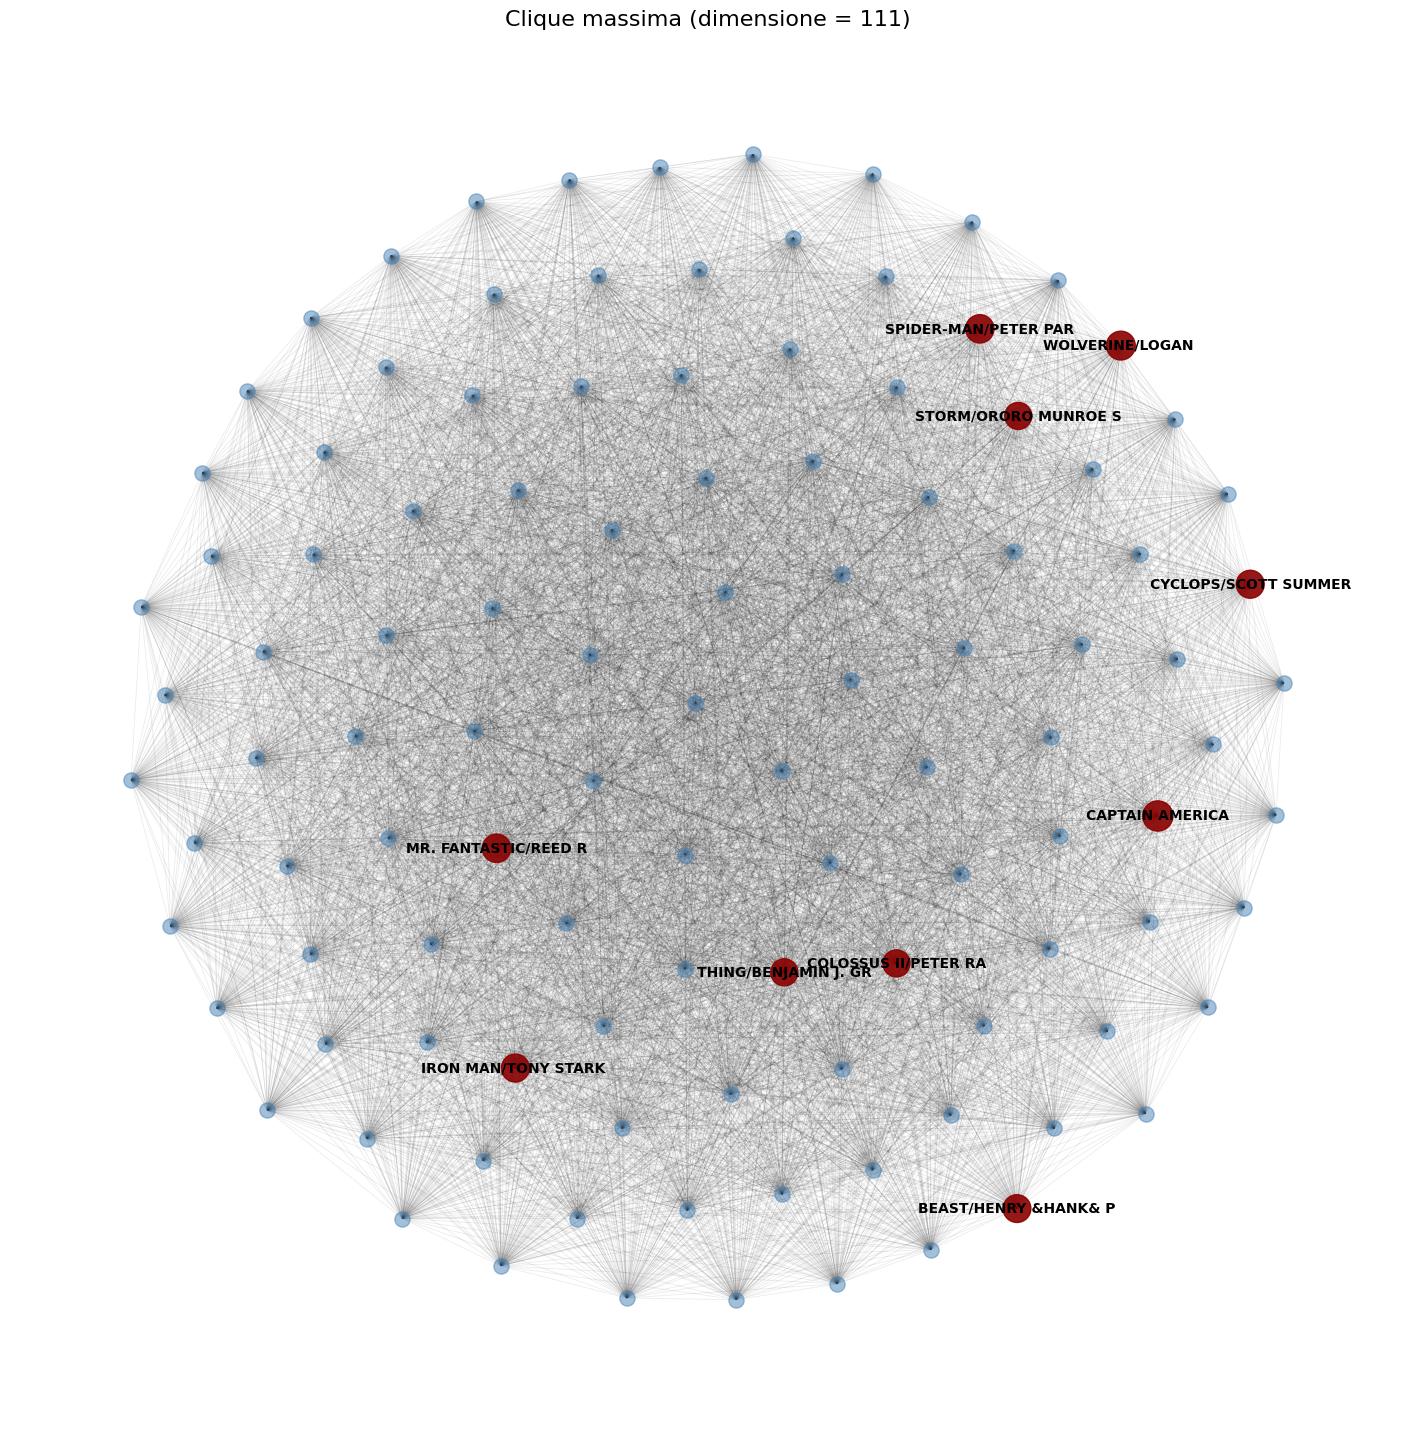

In [7]:
# 3) Personaggi che partecipano alle clique più grandi:
max_size = clique_sizes.max()
largest_cliques = [c for c in cliques if len(c) == max_size]

print(f"Clique massime (dimensione = {max_size}):\n")
print(largest_cliques)
print("----------------------------------------------------\n")




# 4) Centralità basata sulle clique
clique_participation = Counter()

for clique in cliques:
    for node in clique:
        clique_participation[node] += 1

clique_df = (pd.DataFrame.from_dict(clique_participation, orient='index', columns=['clique_count']).sort_values('clique_count', ascending=False))

print("Top 10 personaggi per partecipazione a clique (k >= 3):\n")
print(clique_df.head(10))
print("----------------------------------------------------\n")



# Plot dei punti (3)+(4)

# --- clique massima ---
largest_clique = max(cliques, key=len)
max_size = len(largest_clique)

clique_graph = hero_graph.subgraph(largest_clique)

# --- nodi top ---
top_nodes = list(clique_df.head(10).index)
top_nodes_set = set(top_nodes)

other_nodes = [n for n in clique_graph.nodes() if n not in top_nodes_set]

# dimensione nodi top proporzionale
top_sizes = clique_df.loc[top_nodes, "clique_count"].values / 3000

# --- layout ---
plt.figure(figsize=(18, 18))
pos = nx.spring_layout(clique_graph, k=1.5, iterations=50, seed=42)

# nodi di sfondo
nx.draw_networkx_nodes(clique_graph, pos, nodelist=other_nodes, node_size=120, node_color="steelblue", alpha=0.5)

# nodi top
nx.draw_networkx_nodes(clique_graph, pos, nodelist=top_nodes, node_size=top_sizes, node_color="darkred", alpha=0.9)

# etichette solo top
nx.draw_networkx_labels(clique_graph, pos, labels={n: n for n in top_nodes}, font_size=10, font_weight="bold")

# archi
nx.draw_networkx_edges(clique_graph, pos, alpha=0.08, width=0.6)

plt.title(f"Clique massima (dimensione = {max_size})", fontsize=16)
plt.axis("off")
plt.show()

### Clique vs degree distribution
Idea chiave:
1. Degree (misura locale): quante connessioni dirette ha un nodo --> misura la popolarità
2. Clique (misura strutturale): in quanti sottogruppi completamente connessi è immerso un nodo --> misura l'integrazione sociale.
3. Dunque: due nodi possono avere degree simile ma ruoli strutturali completamente diversi, cioè:
   1. zona in basso a sinistra: sono i nodi marginali, cioè nodi con poche connessioni, poche clique.
   2. degree alto + clique alte: sono i veri hub sociali, cioè personaggi centrali nella narrazione (Captain America, Spider-Man…)
   3. degree alto + clique basse: sono i broker/ponti tra comunità

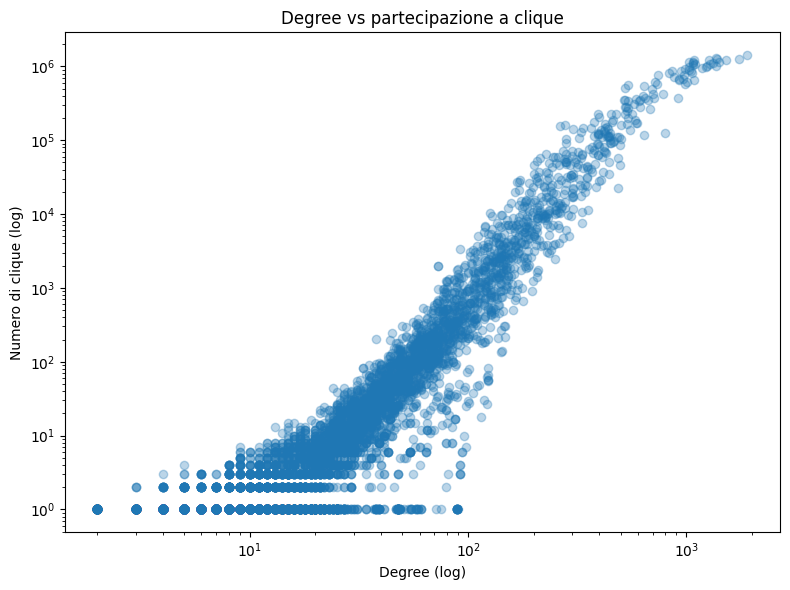

In [8]:
degree_dict = dict(hero_graph.degree())
degree_series = pd.Series(degree_dict)
analysis_df = pd.DataFrame({"degree": degree_series, "clique_count": clique_df["clique_count"]}).dropna()



# Plot
plt.figure(figsize=(8, 6))
plt.scatter(analysis_df["degree"], analysis_df["clique_count"], alpha=0.3)

plt.xscale("log")
plt.yscale("log")

plt.xlabel("Degree (log)")
plt.ylabel("Numero di clique (log)")
plt.title("Degree vs partecipazione a clique")

plt.tight_layout()
plt.show()

### triadi chiuse vs partecipazione a clique:
Usiamo:
1. $triads\_count$: triadi chiuse per nodo.
2. $clique\_df["clique\_count"]$: partecipazione a clique
3. Concetto: chi ha molte triadi chiuse tende a comparire in molte clique

In [9]:
triad_clique_df = pd.DataFrame({"closed_triads": triads_count, "clique_count": clique_df["clique_count"]}).dropna()



# Plot
plt.figure(figsize=(8, 6))
plt.scatter(triad_clique_df["closed_triads"], triad_clique_df["clique_count"], alpha=0.3)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Triadi chiuse (log)")
plt.ylabel("Numero di clique (log)")
plt.title("Triadic closure vs partecipazione a clique")
plt.tight_layout()
plt.show()

NameError: name 'triads_count' is not defined

### Clique density per community (Louvain)
Idea: le clique sono:
1. concentrate dentro le community?
2. oppure attraversano le community?

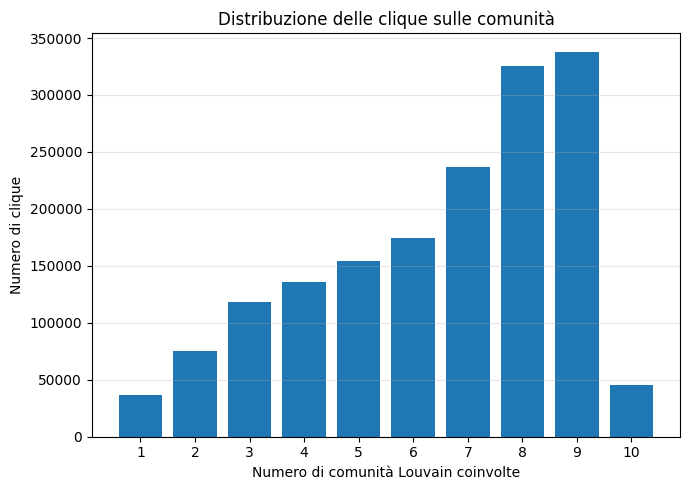

In [10]:
partition = community_louvain.best_partition(hero_graph)

clique_community = []

for c in cliques:
    comms = [partition[n] for n in c]
    clique_community.append(len(set(comms)))


# Interpretazione:
#    =1: clique completamente interna a una community (cioè clique intra-community)
#    >1: clique cross-community (ponte tra community)


cc = pd.Series(clique_community)



# Plot
plt.figure(figsize=(7, 5))
plt.hist(cc, bins=range(1, cc.max() + 2), align="left", rwidth=0.8)

plt.xlabel("Numero di comunità Louvain coinvolte")
plt.ylabel("Numero di clique")
plt.title("Distribuzione delle clique sulle comunità")

plt.xticks(range(1, cc.max() + 1))
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


### Entropia delle clique (diversità)
Idea: quanto è "varia" una clique?
1. Alta entropia = gruppi eterogenei
2. Bassa entropia = gruppi chiusi

In [ ]:
nodes = list(partition.keys())
communities = np.array(list(partition.values()))

comm_map = {c: i for i, c in enumerate(np.unique(communities))}
node_to_comm = {n: comm_map[partition[n]] for n in partition}


def clique_entropy_fast(clique):
    comms = [node_to_comm[n] for n in clique]
    counts = np.bincount(comms)
    return entropy(counts[counts > 0])


entropy_scores = [clique_entropy_fast(c) for c in cliques]

# Normalizzo i risultati tra 0 e 1 prima del Plot
norm_entropy = [
    H / math.log(len(c)) if len(c) > 1 else 0
    for H, c in zip(entropy_scores, cliques)
]

plt.figure(figsize=(8, 5))
plt.hist(norm_entropy, bins=40)
plt.xlabel("Entropia normalizzata")
plt.ylabel("Numero di clique")
plt.title("Distribuzione entropia normalizzata")
plt.show()


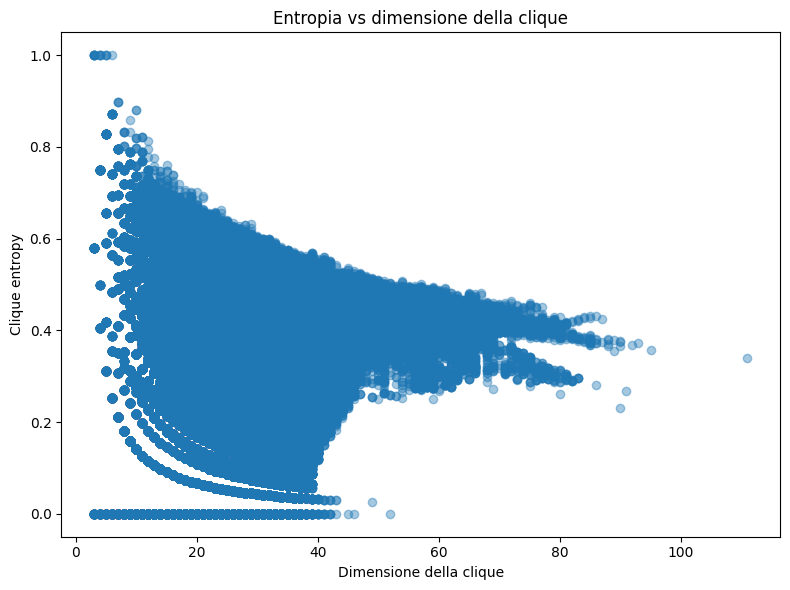

In [ ]:
# Scatter-plot: Entropia vs dimensione della clique
clique_sizes = [len(c) for c in cliques]

plt.figure(figsize=(8, 6))
plt.scatter(clique_sizes, norm_entropy, alpha=0.4)
plt.xlabel("Dimensione della clique")
plt.ylabel("Clique entropy")
plt.title("Entropia vs dimensione della clique")
plt.tight_layout()
plt.show()


### Robustezza delle clique (attack simulation)
Idea: cosa succede alle clique se rimuovo:
1. i nodi più centrali
2. i nodi random

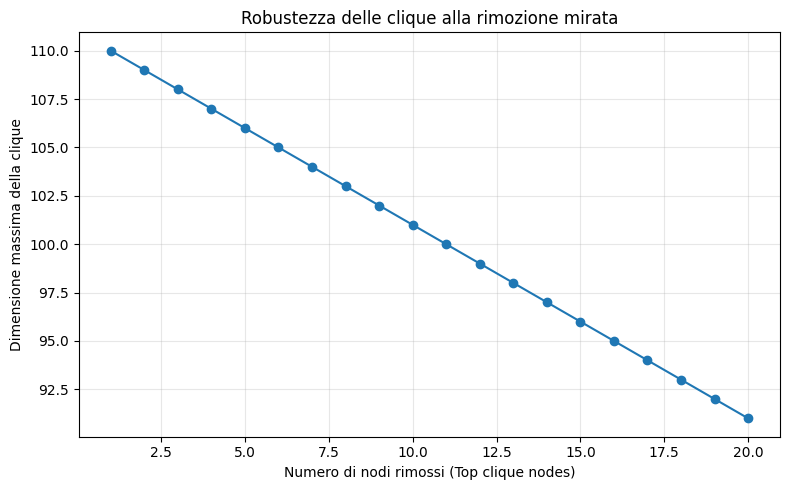

In [ ]:
def clique_resilience(G, nodes_to_remove):
    G_tmp = G.copy()
    G_tmp.remove_nodes_from(nodes_to_remove)
    return max(len(c) for c in nx.find_cliques(G_tmp))


# Caso 1: tolgo solo i primi k nodes
resilience_curve = []

ordered_nodes = list(clique_df.index)

for k in range(1, 21):
    removed = ordered_nodes[:k]
    max_clique = clique_resilience(hero_graph, removed)
    resilience_curve.append(max_clique)


plt.figure(figsize=(8, 5))
plt.plot(range(1, 21), resilience_curve, marker='o')
plt.xlabel("Numero di nodi rimossi (Top clique nodes)")
plt.ylabel("Dimensione massima della clique")
plt.title("Robustezza delle clique alla rimozione mirata")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


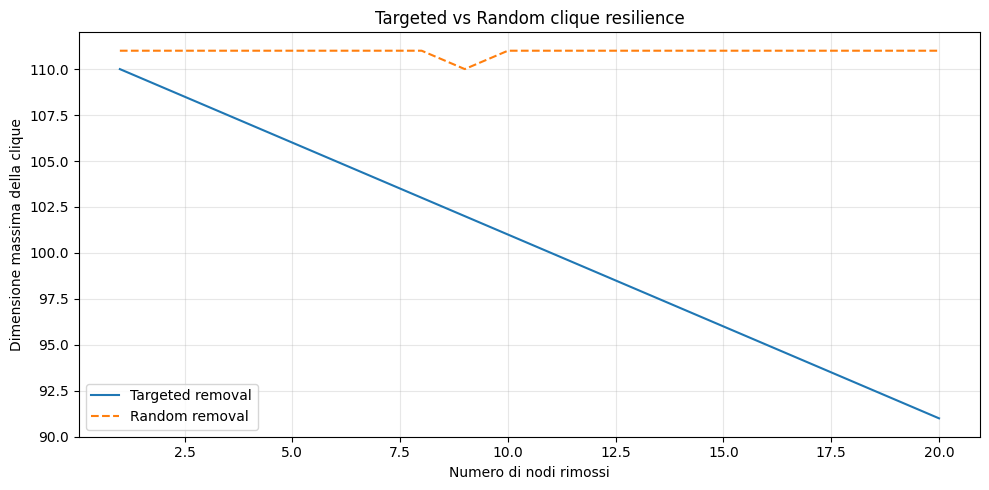

In [ ]:
# Caso 2: tolgo nodi random

random_curve = []

nodes = list(hero_graph.nodes())

for k in range(1, 21):
    random_nodes = random.sample(nodes, k)
    max_clique = clique_resilience(hero_graph, random_nodes)
    random_curve.append(max_clique)


plt.figure(figsize=(8, 5))
plt.plot(range(1, 21), resilience_curve, label="Targeted removal")
plt.plot(range(1, 21), random_curve, label="Random removal", linestyle="--")
plt.xlabel("Numero di nodi rimossi")
plt.ylabel("Dimensione massima della clique")
plt.title("Targeted vs Random clique resilience")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
